In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
import joblib

In [17]:
lr_model = joblib.load("../models/logistic_regression.pkl")
rf_model = joblib.load("../models/random_forest.pkl")
xgb_model = joblib.load("../models/xgboost.pkl")
nn_model = joblib.load("../models/neural_network.pkl")

In [18]:
df = pd.read_csv("../data/processed/SWaT_cleaned.csv")

In [19]:
print("Shape:", df.shape)
print(df.head())
print(df.columns)

Shape: (1441719, 46)
                 Timestamp    FIT101    LIT101  P101  P102    AIT202  \
0   28/12/2015 10:00:00 AM  2.427057  522.8467     2     1  8.396437   
1   28/12/2015 10:00:01 AM  2.446274  522.8860     2     1  8.396437   
2   28/12/2015 10:00:02 AM  2.489191  522.8467     2     1  8.394514   
3   28/12/2015 10:00:03 AM  2.534350  522.9645     2     1  8.394514   
4   28/12/2015 10:00:04 AM  2.569260  523.4748     2     1  8.394514   

     AIT203    FIT201  P203  P205  ...  P501  P502    PIT501    PIT502  \
0  328.6337  2.445391     2     2  ...     2     1  250.8652  1.649953   
1  328.6337  2.445391     2     2  ...     2     1  250.8652  1.649953   
2  328.6337  2.442316     2     2  ...     2     1  250.8812  1.649953   
3  328.6337  2.442316     2     2  ...     2     1  250.8812  1.649953   
4  328.6337  2.443085     2     2  ...     2     1  250.8812  1.649953   

     PIT503    FIT601  P601  P602  P603  Normal/Attack  
0  189.5988  0.000128     1     1     1     

In [20]:
X = df.drop(columns=["Normal/Attack", "Timestamp"])
y = df["Normal/Attack"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (1441719, 44)
y shape: (1441719,)
Normal/Attack
0    1387098
1      54621
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_test:", X_test.shape)
print("y_test:")
print(y_test.value_counts())

X_test: (288344, 44)
y_test:
Normal/Attack
0    277420
1     10924
Name: count, dtype: int64


In [22]:
scaler_lr = joblib.load("../models/logistic_scaler.pkl")
scaler_rf = joblib.load("../models/random_forest_scaler.pkl")
scaler_nn = joblib.load("../models/neural_network_scaler.pkl")

In [23]:
X_test_scaled = scaler_lr.transform(X_test)

In [24]:
print(X_test_scaled.shape)

(288344, 44)


In [25]:
# Probability scores for the positive class (Attack = 1)

lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
nn_proba = nn_model.predict_proba(X_test_scaled)[:, 1]

print("Probability scores generated successfully.")

Probability scores generated successfully.


In [26]:
from sklearn.metrics import roc_auc_score

roc_auc_results = {
    "Logistic Regression": roc_auc_score(y_test, lr_proba),
    "Random Forest": roc_auc_score(y_test, rf_proba),
    "XGBoost": roc_auc_score(y_test, xgb_proba),
    "Neural Network": roc_auc_score(y_test, nn_proba)
}

for model_name, score in roc_auc_results.items():
    print(f"{model_name}: {score:.4f}")

Logistic Regression: 0.9755
Random Forest: 1.0000
XGBoost: 1.0000
Neural Network: 1.0000


In [27]:
from sklearn.metrics import average_precision_score

pr_auc_results = {
    "Logistic Regression": average_precision_score(y_test, lr_proba),
    "Random Forest": average_precision_score(y_test, rf_proba),
    "XGBoost": average_precision_score(y_test, xgb_proba),
    "Neural Network": average_precision_score(y_test, nn_proba)
}

for model_name, score in pr_auc_results.items():
    print(f"{model_name}: {score:.4f}")

Logistic Regression: 0.8363
Random Forest: 0.9999
XGBoost: 0.9990
Neural Network: 0.9988


In [28]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

print(feature_importance.head(20))

PIT501     0.092221
PIT503     0.078074
FIT503     0.076806
AIT402     0.069156
PIT502     0.064957
FIT401     0.059470
AIT501     0.053811
LIT301     0.045330
AIT502     0.045131
LIT401     0.042922
AIT202     0.033366
FIT504     0.032894
DPIT301    0.030599
FIT501     0.028665
LIT101     0.028354
AIT504     0.024526
UV401      0.024045
AIT203     0.022042
FIT201     0.020824
AIT503     0.020396
dtype: float64


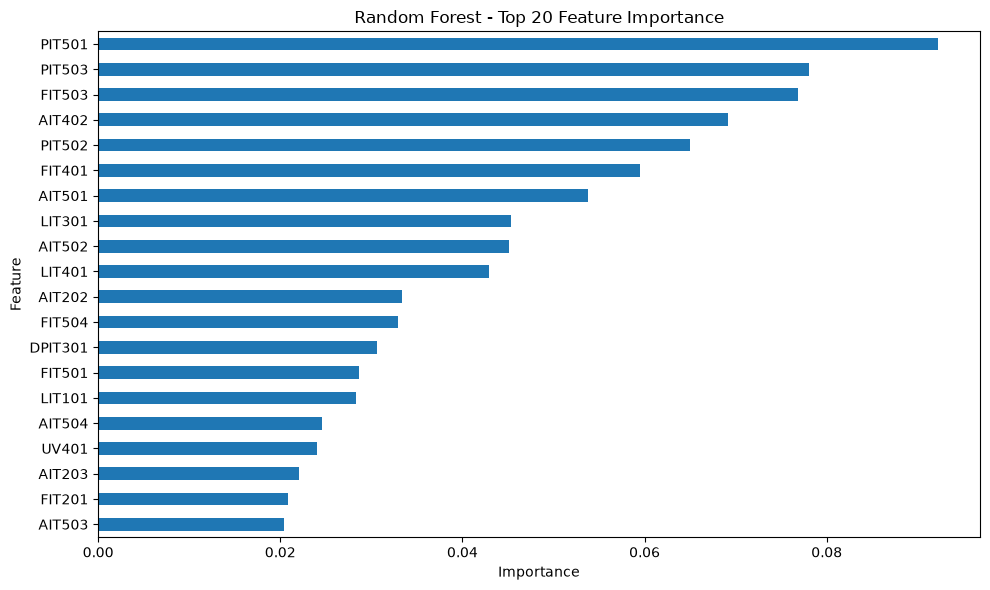

In [29]:
plt.figure(figsize=(10, 6))

feature_importance.head(20).sort_values().plot(kind="barh")

plt.title("Random Forest - Top 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("../images/random_forest_feature_importance.png",
            dpi=300, bbox_inches="tight")

plt.show()

In [30]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_model,
    X_test_scaled,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="average_precision",
    n_jobs=-1
)

perm_results = pd.Series(
    perm_importance.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(perm_results.head(20))

LIT301     0.002575
AIT402     0.002002
LIT401     0.001907
AIT502     0.001190
AIT202     0.001184
PIT501     0.001048
AIT501     0.001037
LIT101     0.000978
AIT504     0.000828
FIT201     0.000668
PIT503     0.000635
DPIT301    0.000607
FIT301     0.000589
PIT502     0.000520
AIT203     0.000446
AIT503     0.000433
P102       0.000395
P302       0.000359
FIT101     0.000341
FIT401     0.000226
dtype: float64


In [31]:
# Make a copy for leakage investigation
df_time = df.copy()

# Convert Timestamp to datetime
df_time["Timestamp"] = pd.to_datetime(
    df_time["Timestamp"],
    format="mixed",
    dayfirst=True
)

# Sort chronologically
df_time = df_time.sort_values("Timestamp").reset_index(drop=True)

print("First timestamp:", df_time["Timestamp"].iloc[0])
print("Last timestamp:", df_time["Timestamp"].iloc[-1])
print("Shape:", df_time.shape)

First timestamp: 2015-12-22 16:00:00
Last timestamp: 2016-01-02 14:59:59
Shape: (1441719, 46)


In [32]:
print(df_time["Normal/Attack"].value_counts())
print(
    df_time["Normal/Attack"]
    .value_counts(normalize=True) * 100
)

Normal/Attack
0    1387098
1      54621
Name: count, dtype: int64
Normal/Attack
0    96.211398
1     3.788602
Name: proportion, dtype: float64


In [33]:
# Time-based split: first 80% for training, last 20% for testing

split_index = int(len(df_time) * 0.8)

train_time = df_time.iloc[:split_index].copy()
test_time = df_time.iloc[split_index:].copy()

print("Train shape:", train_time.shape)
print("Test shape:", test_time.shape)

print("\nTrain labels:")
print(train_time["Normal/Attack"].value_counts())

print("\nTest labels:")
print(test_time["Normal/Attack"].value_counts())

Train shape: (1153375, 46)
Test shape: (288344, 46)

Train labels:
Normal/Attack
0    1143996
1       9379
Name: count, dtype: int64

Test labels:
Normal/Attack
0    243102
1     45242
Name: count, dtype: int64


In [34]:
print("\nTrain percentage:")
print(train_time["Normal/Attack"].value_counts(normalize=True) * 100)

print("\nTest percentage:")
print(test_time["Normal/Attack"].value_counts(normalize=True) * 100)


Train percentage:
Normal/Attack
0    99.186821
1     0.813179
Name: proportion, dtype: float64

Test percentage:
Normal/Attack
0    84.309713
1    15.690287
Name: proportion, dtype: float64


In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# Remove Timestamp
X_train_time = train_time.drop(
    columns=["Timestamp", "Normal/Attack"]
)

X_test_time = test_time.drop(
    columns=["Timestamp", "Normal/Attack"]
)

y_train_time = train_time["Normal/Attack"]
y_test_time = test_time["Normal/Attack"]

print("X_train_time:", X_train_time.shape)
print("X_test_time:", X_test_time.shape)

X_train_time: (1153375, 44)
X_test_time: (288344, 44)


In [36]:
time_scaler = StandardScaler()

X_train_time_scaled = time_scaler.fit_transform(X_train_time)
X_test_time_scaled = time_scaler.transform(X_test_time)

print("Scaled train:", X_train_time_scaled.shape)
print("Scaled test:", X_test_time_scaled.shape)

Scaled train: (1153375, 44)
Scaled test: (288344, 44)


In [37]:
rf_time = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_time.fit(X_train_time_scaled, y_train_time)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [38]:
y_pred_time = rf_time.predict(X_test_time_scaled)
y_proba_time = rf_time.predict_proba(X_test_time_scaled)[:, 1]

print(classification_report(y_test_time, y_pred_time))

print("ROC-AUC:",
      roc_auc_score(y_test_time, y_proba_time))

print("PR-AUC:",
      average_precision_score(y_test_time, y_proba_time))

              precision    recall  f1-score   support

           0       0.84      1.00      0.92    243102
           1       0.78      0.00      0.01     45242

    accuracy                           0.84    288344
   macro avg       0.81      0.50      0.46    288344
weighted avg       0.83      0.84      0.77    288344

ROC-AUC: 0.8782161483922377
PR-AUC: 0.8142908566511826


In [39]:
scale_pos_weight_time = (
    (y_train_time == 0).sum()
    / (y_train_time == 1).sum()
)

print("scale_pos_weight:", scale_pos_weight_time)

scale_pos_weight: 121.97419767565839


In [40]:
from xgboost import XGBClassifier

xgb_time = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_time,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_time.fit(X_train_time, y_train_time)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [41]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

y_pred_xgb_time = xgb_time.predict(X_test_time)

y_proba_xgb_time = xgb_time.predict_proba(
    X_test_time
)[:, 1]

print(classification_report(
    y_test_time,
    y_pred_xgb_time
))

print(
    "ROC-AUC:",
    roc_auc_score(y_test_time, y_proba_xgb_time)
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test_time,
        y_proba_xgb_time
    )
)

              precision    recall  f1-score   support

           0       0.95      0.98      0.97    243102
           1       0.88      0.71      0.79     45242

    accuracy                           0.94    288344
   macro avg       0.92      0.85      0.88    288344
weighted avg       0.94      0.94      0.94    288344

ROC-AUC: 0.8639986704021949
PR-AUC: 0.8067395614329836


In [42]:
from sklearn.neural_network import MLPClassifier

nn_time = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

nn_time.fit(
    X_train_time_scaled,
    y_train_time
)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",30
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the 

In [43]:
y_pred_nn_time = nn_time.predict(
    X_test_time_scaled
)

y_proba_nn_time = nn_time.predict_proba(
    X_test_time_scaled
)[:, 1]

In [44]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

print(classification_report(
    y_test_time,
    y_pred_nn_time
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_time,
        y_proba_nn_time
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test_time,
        y_proba_nn_time
    )
)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95    243102
           1       0.80      0.59      0.68     45242

    accuracy                           0.91    288344
   macro avg       0.86      0.78      0.81    288344
weighted avg       0.91      0.91      0.91    288344

ROC-AUC: 0.8582828102522506
PR-AUC: 0.6157858395024334


In [45]:
from sklearn.linear_model import LogisticRegression

lr_time = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_time.fit(
    X_train_time_scaled,
    y_train_time
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [46]:
y_pred_lr_time = lr_time.predict(
    X_test_time_scaled
)

y_proba_lr_time = lr_time.predict_proba(
    X_test_time_scaled
)[:, 1]

In [47]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

print(classification_report(
    y_test_time,
    y_pred_lr_time
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_time,
        y_proba_lr_time
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test_time,
        y_proba_lr_time
    )
)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96    243102
           1       0.80      0.79      0.79     45242

    accuracy                           0.94    288344
   macro avg       0.88      0.88      0.88    288344
weighted avg       0.94      0.94      0.94    288344

ROC-AUC: 0.8909162266137591
PR-AUC: 0.8339500429944571


In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (
        y_proba_lr_time >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test_time,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_time,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_time,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

    Threshold  Precision    Recall        F1
0        0.10   0.602154  0.799721  0.687016
1        0.15   0.641871  0.797622  0.711320
2        0.20   0.673399  0.795898  0.729542
3        0.25   0.699373  0.794041  0.743707
4        0.30   0.721776  0.792914  0.755674
5        0.35   0.742000  0.791875  0.766127
6        0.40   0.760772  0.791057  0.775619
7        0.45   0.779730  0.790571  0.785113
8        0.50   0.797861  0.789996  0.793909
9        0.55   0.812658  0.789576  0.800951
10       0.60   0.825387  0.789355  0.806969
11       0.65   0.837927  0.788957  0.812705
12       0.70   0.848791  0.788493  0.817532
13       0.75   0.858605  0.788007  0.821792
14       0.80   0.868325  0.787543  0.825963
15       0.85   0.877384  0.787012  0.829745
16       0.90   0.887597  0.786305  0.833886


In [49]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best threshold:")
print(best_threshold_row)

Best threshold:
Threshold    0.900000
Precision    0.887597
Recall       0.786305
F1           0.833886
Name: 16, dtype: float64


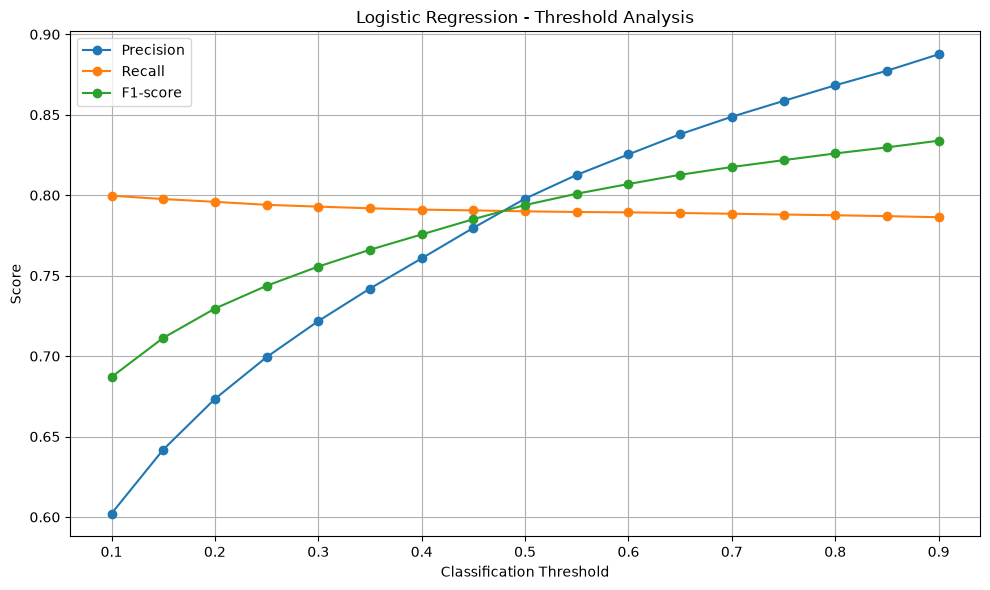

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression - Threshold Analysis")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../images/logistic_regression_threshold_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:


rf_tuning = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

In [52]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
time_cv = TimeSeriesSplit(n_splits=3)

rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="average_precision",
    cv=time_cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(
    X_train_time_scaled,
    y_train_time
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\hp\Desktop\advanced\Capstone-Project\venv\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 15, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, `

In [53]:
print("Best parameters:")
print(rf_random_search.best_params_)

print("\nBest CV PR-AUC:")
print(rf_random_search.best_score_)

Best parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}

Best CV PR-AUC:
nan


In [54]:
best_rf_time = rf_random_search.best_estimator_

y_pred_rf_tuned = best_rf_time.predict(
    X_test_time_scaled
)

y_proba_rf_tuned = best_rf_time.predict_proba(
    X_test_time_scaled
)[:, 1]

In [55]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

print(classification_report(
    y_test_time,
    y_pred_rf_tuned
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_time,
        y_proba_rf_tuned
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test_time,
        y_proba_rf_tuned
    )
)

              precision    recall  f1-score   support

           0       0.84      1.00      0.92    243102
           1       0.78      0.00      0.01     45242

    accuracy                           0.84    288344
   macro avg       0.81      0.50      0.46    288344
weighted avg       0.83      0.84      0.77    288344

ROC-AUC: 0.9001103086920257
PR-AUC: 0.8406735549510931


In [56]:
cv_results = pd.DataFrame(rf_random_search.cv_results_)

print(
    cv_results[
        [
            "params",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ].sort_values("mean_test_score", ascending=False)
)

                                              params  mean_test_score  \
0  {'n_estimators': 100, 'min_samples_split': 5, ...              NaN   
1  {'n_estimators': 100, 'min_samples_split': 10,...              NaN   
2  {'n_estimators': 100, 'min_samples_split': 5, ...              NaN   
3  {'n_estimators': 100, 'min_samples_split': 10,...              NaN   
4  {'n_estimators': 100, 'min_samples_split': 10,...              NaN   
5  {'n_estimators': 100, 'min_samples_split': 5, ...              NaN   
6  {'n_estimators': 300, 'min_samples_split': 2, ...              NaN   
7  {'n_estimators': 200, 'min_samples_split': 2, ...              NaN   
8  {'n_estimators': 200, 'min_samples_split': 10,...              NaN   
9  {'n_estimators': 200, 'min_samples_split': 5, ...              NaN   

   std_test_score  rank_test_score  
0             NaN                1  
1             NaN                1  
2             NaN                1  
3             NaN                1  
4          

In [57]:
from sklearn.model_selection import TimeSeriesSplit

time_cv = TimeSeriesSplit(n_splits=3)

for fold, (train_idx, val_idx) in enumerate(
    time_cv.split(X_train_time_scaled),
    start=1
):
    print(f"\nFold {fold}")

    print("Train:")
    print(
        y_train_time.iloc[train_idx].value_counts()
    )

    print("Validation:")
    print(
        y_train_time.iloc[val_idx].value_counts()
    )


Fold 1
Train:
Normal/Attack
0    288346
Name: count, dtype: int64
Validation:
Normal/Attack
0    288343
Name: count, dtype: int64

Fold 2
Train:
Normal/Attack
0    576689
Name: count, dtype: int64
Validation:
Normal/Attack
0    288343
Name: count, dtype: int64

Fold 3
Train:
Normal/Attack
0    865032
Name: count, dtype: int64
Validation:
Normal/Attack
0    278964
1      9379
Name: count, dtype: int64


In [58]:
df["Normal/Attack"].value_counts()

Normal/Attack
0    1387098
1      54621
Name: count, dtype: int64

In [61]:
# Save the tuned Random Forest as the final model

final_model = rf_random_search.best_estimator_

joblib.dump(
    final_model,
    "../models/final_random_forest.pkl"
)

joblib.dump(
    time_scaler,
    "../models/final_random_forest_scaler.pkl"
)


print(final_model)

RandomForestClassifier(class_weight='balanced', max_features='log2',
                       min_samples_leaf=2, min_samples_split=5, n_jobs=-1,
                       random_state=42)


In [62]:
# Verify saved files

saved_model = joblib.load(
    "../models/final_random_forest.pkl"
)

saved_scaler = joblib.load(
    "../models/final_random_forest_scaler.pkl"
)

print(saved_model)

print(saved_scaler)

RandomForestClassifier(class_weight='balanced', max_features='log2',
                       min_samples_leaf=2, min_samples_split=5, n_jobs=-1,
                       random_state=42)
StandardScaler()
